# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/studentkrithika
/kaggle/input/datasets/studentkrithika/idrid-dataset
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/2. Haemorrhages
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/5. Optic Disc
/kaggle/input/datasets/studentkrithika/idrid-

1. IMAGE COUNTS
----------------------------------------
Training Images = 54
Testing Images  = 27
Image count verification passed.

2A. TRAINING MASK COUNTS
----------------------------------------
Microaneurysms: 54
Haemorrhages: 53
Hard Exudates: 54
Soft Exudates: 26

2B. TESTING MASK COUNTS
----------------------------------------
Microaneurysms: 27
Haemorrhages: 27
Hard Exudates: 27
Soft Exudates: 14

3. SAMPLE MATCHING CHECK
----------------------------------------
Split: train
Image ID: IDRiD_01
Original Image: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/1. Original Images/a. Training Set/IDRiD_01.jpg
MA Mask: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms/IDRiD_01_MA.tif
HE Mask: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/2. Haemorrhages/IDRiD_01_HE.tif
EX Mask: /kaggle/input/datasets/student

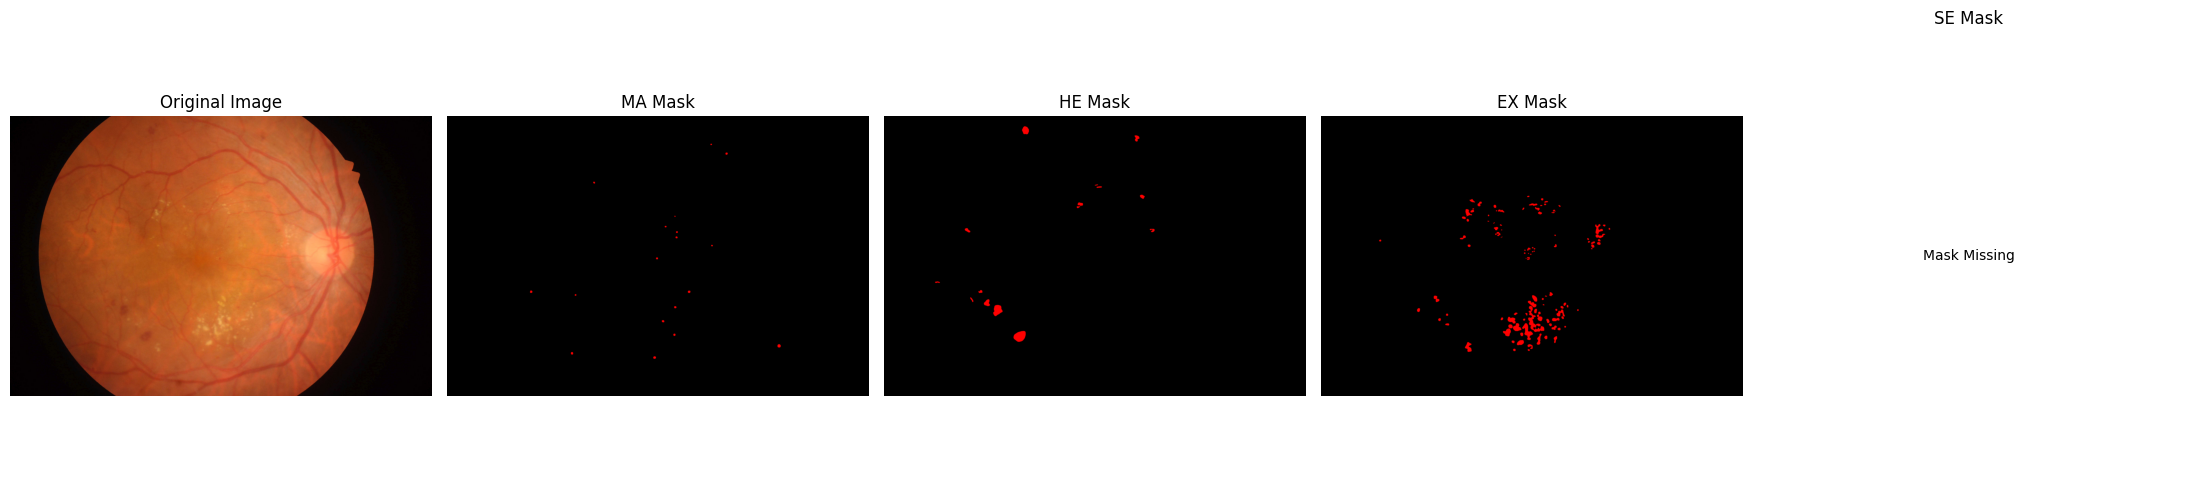

3. SAMPLE MATCHING CHECK
----------------------------------------
Split: test
Image ID: IDRiD_55
Original Image: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/1. Original Images/b. Testing Set/IDRiD_55.jpg
MA Mask: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/1. Microaneurysms/IDRiD_55_MA.tif
HE Mask: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/2. Haemorrhages/IDRiD_55_HE.tif
EX Mask: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/3. Hard Exudates/IDRiD_55_EX.tif
SE Mask: /kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/4. Soft Exudates/IDRiD_55_SE.tif


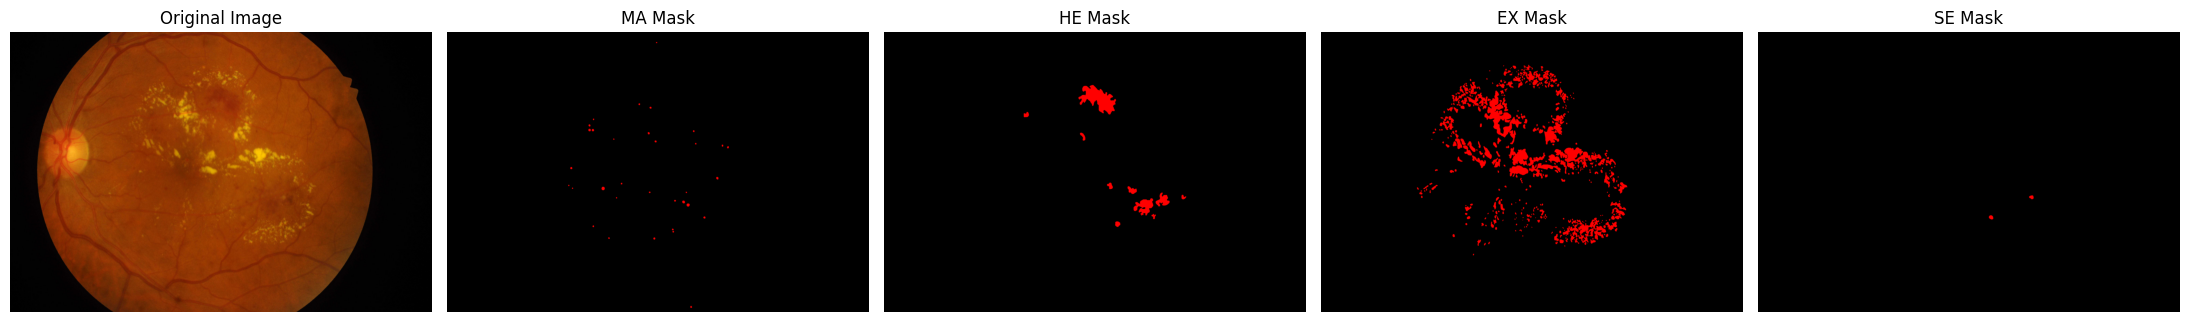

In [2]:
import os
import glob
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

# =========================
# Paths
# =========================

BASE = Path("/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation")

IMG_TRAIN_DIR = BASE / "1. Original Images" / "a. Training Set"
IMG_TEST_DIR  = BASE / "1. Original Images" / "b. Testing Set"

GT_TRAIN_DIR = BASE / "2. All Segmentation Groundtruths" / "a. Training Set"
GT_TEST_DIR  = BASE / "2. All Segmentation Groundtruths" / "b. Testing Set"

MASK_DIRS = {
    "Microaneurysms": "1. Microaneurysms",
    "Haemorrhages": "2. Haemorrhages",
    "Hard Exudates": "3. Hard Exudates",
    "Soft Exudates": "4. Soft Exudates",
}

SHORT_NAMES = {
    "Microaneurysms": "MA",
    "Haemorrhages": "HE",
    "Hard Exudates": "EX",
    "Soft Exudates": "SE",
}

# =========================
# Helpers
# =========================

def list_files(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]
    files = []
    for ext in exts:
        files.extend(glob.glob(str(folder / ext)))
    return sorted(files)

def get_image_id(path):
    """
    Extracts ID like IDRiD_01 from filenames such as:
    IDRiD_01.jpg
    IDRiD_01_MA.tif
    IDRiD_01_EX.png
    """
    stem = Path(path).stem
    parts = stem.split("_")

    if len(parts) >= 2:
        return parts[0] + "_" + parts[1]

    return stem

def make_id_map(files):
    return {get_image_id(f): f for f in files}

def count_and_show_images():
    train_images = list_files(IMG_TRAIN_DIR)
    test_images = list_files(IMG_TEST_DIR)

    print("1. IMAGE COUNTS")
    print("-" * 40)
    print(f"Training Images = {len(train_images)}")
    print(f"Testing Images  = {len(test_images)}")

    assert len(train_images) == 54, f"Expected 54 training images, found {len(train_images)}"
    assert len(test_images) == 27, f"Expected 27 testing images, found {len(test_images)}"

    print("Image count verification passed.\n")

def count_masks(split_name, gt_dir):
    print(f"{split_name} MASK COUNTS")
    print("-" * 40)

    counts = {}

    for mask_name, folder_name in MASK_DIRS.items():
        mask_folder = gt_dir / folder_name
        mask_files = list_files(mask_folder)

        counts[mask_name] = len(mask_files)
        print(f"{mask_name}: {len(mask_files)}")

    print()
    return counts

def visualize_sample(split="train", image_id=None):
    if split == "train":
        img_dir = IMG_TRAIN_DIR
        gt_dir = GT_TRAIN_DIR
    else:
        img_dir = IMG_TEST_DIR
        gt_dir = GT_TEST_DIR

    image_files = list_files(img_dir)
    image_map = make_id_map(image_files)

    if image_id is None:
        image_id = sorted(image_map.keys())[0]

    if image_id not in image_map:
        raise ValueError(f"Image ID {image_id} not found in {split} images.")

    original_path = image_map[image_id]

    mask_paths = {}

    for mask_name, folder_name in MASK_DIRS.items():
        mask_folder = gt_dir / folder_name
        mask_files = list_files(mask_folder)
        mask_map = make_id_map(mask_files)

        if image_id in mask_map:
            mask_paths[mask_name] = mask_map[image_id]
        else:
            mask_paths[mask_name] = None

    print("3. SAMPLE MATCHING CHECK")
    print("-" * 40)
    print(f"Split: {split}")
    print(f"Image ID: {image_id}")
    print(f"Original Image: {original_path}")

    for mask_name, path in mask_paths.items():
        print(f"{SHORT_NAMES[mask_name]} Mask: {path}")

    # Display: Original, MA, HE, EX, SE
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    original = Image.open(original_path)
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    display_order = [
        "Microaneurysms",
        "Haemorrhages",
        "Hard Exudates",
        "Soft Exudates",
    ]

    for ax, mask_name in zip(axes[1:], display_order):
        path = mask_paths[mask_name]

        if path is not None:
            mask = Image.open(path)
            ax.imshow(mask, cmap="gray")
            ax.set_title(f"{SHORT_NAMES[mask_name]} Mask")
        else:
            ax.text(0.5, 0.5, "Mask Missing", ha="center", va="center")
            ax.set_title(f"{SHORT_NAMES[mask_name]} Mask")

        ax.axis("off")

    plt.tight_layout()
    plt.show()

# =========================
# Run checks
# =========================

count_and_show_images()

train_mask_counts = count_masks("2A. TRAINING", GT_TRAIN_DIR)
test_mask_counts = count_masks("2B. TESTING", GT_TEST_DIR)

# Change image_id if you want a specific sample, example:
# visualize_sample(split="train", image_id="IDRiD_01")
visualize_sample(split="train", image_id="IDRiD_01")

visualize_sample(split="test", image_id="IDRiD_55")